# MSDM 5002 HW3

Author：    LAN Tianwei 藍天蔚<br>
ID：        21230969<br>
Email：     tlanaa@connect.ust.hk<br>

# Q1: graph of simple functions

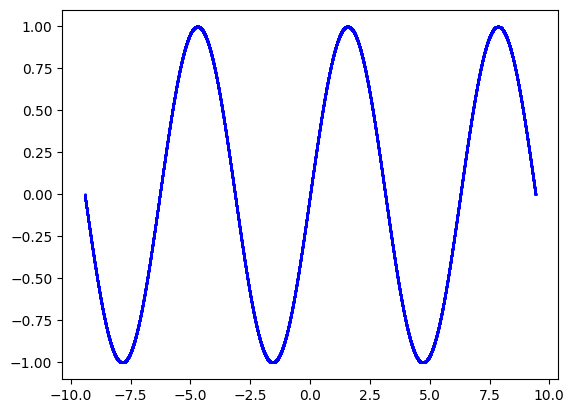

In [179]:
# function 1
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3*np.pi, 3*np.pi, 20000)

sin_x = np.sin(x)
cos_x = np.cos(x)
condition = sin_x - cos_x >= 0
y = np.where(condition, np.maximum(sin_x, cos_x), np.minimum(sin_x, cos_x))

plt.scatter(x, y, s=1, color='blue', alpha=0.6)
plt.savefig("1(1)fun1.png")
plt.show()

C:\Users\86137\AppData\Local\Temp\ipykernel_11588\3344767108.py:13: RuntimeWarning: divide by zero encountered in divide
  y = np.where(is_even,0.5, np.where(is_odd,-0.5,np.cos(1/x)))
C:\Users\86137\AppData\Local\Temp\ipykernel_11588\3344767108.py:13: RuntimeWarning: invalid value encountered in cos
  y = np.where(is_even,0.5, np.where(is_odd,-0.5,np.cos(1/x)))


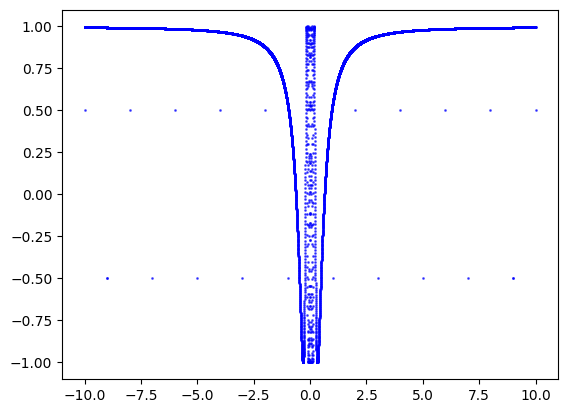

In [180]:
# funtion 2: 
import numpy as np
import matplotlib.pyplot as plt

x_sample = np.linspace(-10, 10, 20000)
x_int = np.arange(-10, 11)
x = np.unique(np.concatenate([x_sample, x_int]))

x_r = np.round(x)
is_int = np.isclose(x, x_r)
is_odd = (x_r % 2 == 1) & is_int
is_even = (x_r % 2 == 0) & is_int
y = np.where(is_even,0.5, np.where(is_odd,-0.5,np.cos(1/x)))

plt.scatter(x, y, s=1, color='blue', alpha=0.6)
plt.savefig("1(2)fun2.png")
plt.show()

# Q2: Hessian Matrix

for $f(x_1,x_2,...,x_n)= e^{x_1^2+x_2^2+...+x_n^2}$, when $i=j$:
$$
A=exp(\sum_{k\neq i}{x_k^2}), \quad Ae^{x_i^2} = f
$$
$$
\frac{\partial^2 f}{\partial x_i^2}=A(e^{x_i^2})''=A(2+4x_i^2)e^{x_i^2}
$$
$$
=(2+4x_i^2)f = (2+4x_i x_j)f 
$$
when $i \neq j$:
$$
B=exp(\sum_{k\neq i,j}{x_k^2}), \quad Be^{x_i^2}e^{x_j^2} = f
$$
$$
\frac{\partial^2 f}{\partial x_i \partial x_j} = B(e^{x_i^2})'(e^{x_j^2})'=4 B x_i x_j e^{x_i^2} e^{x_j^2} = 4 x_i x_j f
$$
so just broadcast an array with $4 x_i x_j f$ (outer product) in every position, then add $2f$ to the main diagonal.

*I can proudly announce that I only used 4 lines of codes*

In [181]:
import numpy as np

def H(*nums):
    t = np.array(nums)
    f = np.exp(np.dot(t, t)) 
    mat = 4 * f * np.outer(t, t)
    np.fill_diagonal(mat, mat.diagonal() + 2 * f)
    return mat

print(H(1,2))
# print((2+4*1*1)*np.exp(5))
# print((4*1*2)*np.exp(5))
# print((2+4*2*2)*np.exp(5))
print()
print(H(1,2,3))
# print((2+4*1*1)*np.exp(14))
# print((4*1*2)*np.exp(14))
# print((4*1*3)*np.exp(14))
# print((2+4*2*2)*np.exp(14))
# print((4*2*3)*np.exp(14))
# print((2+4*3*3)*np.exp(14))
    

[[ 890.47895462 1187.30527282]
 [1187.30527282 2671.43686385]]

[[ 7215625.70498866  9620834.27331821 14431251.40997732]
 [ 9620834.27331821 21646877.11496598 28862502.81995464]
 [14431251.40997732 28862502.81995464 45698962.79826152]]


# Q3: Estimate circle area

## Part a

Create a 1000×1000 matrix stand for the grid, each circle randomly choose center and have radius = 200.

Normally, we calculate the Eculidean distance of 5 centers and each grid, then set TRUE stand for the grid in one of the circles if any distance smaller than the radius. But if use *for* loop, it's too slow.

Use *Numpy*! Broadcast 5 Eculidean distance matrices based on center points, then transfer them into boolean MASK matrices by the condition of *less than 200*, and finally calculate them by *or*! No need to notice the parts outside the grid.

In [141]:
import numpy as np

r = 200
N = 1000

def CreateMask(center, r, N):
    x, y = center
    rows, cols = np.ogrid[:N, :N]
    mask = (rows - y)**2 + (cols - x)**2 <= r**2
    return mask

centers = np.random.uniform(0, 1000, size=(5, 2))
mask = []
for i in range(5):
    mask.append(CreateMask(centers[i],r,N))

union_mask = np.logical_or.reduce(mask) # Calculate by "OR"
print("Estimated Area is:",np.sum(union_mask)/100**2)

Estimated Area is: 38.4447


The outputs never exceed $S_{max}=2×2×\pi×5 \approx 60$, and maintains around 30-40, which meets theory and expectation.

## Part b
Similar to part a, just differs in mask calculating.

When we calculate how many grid cells are covered, we are still calculating the Euclidean distance, but we need to rotate the grid coordinate system in the opposite direction by the angle. That is, put the grid into a coordinate system with the center of the square as the origin and the sides as the coordinate axes, and then check whether the grid coordinates are all less than half the length of the square side.


In [140]:
import numpy as np

l = 300
N = 1000

def CreateMask2(center, angle, l, N):

    cx, cy = center
    half = l / 2.0
    x, y = np.ogrid[:N, :N] 
    
    # move to square's center
    dx = x - cx
    dy = y - cy
    
    # inverse rotation
    cos_a = np.cos(-angle)
    sin_a = np.sin(-angle)
    
    # calculate by rotation formula
    x_rot = dx * cos_a - dy * sin_a
    y_rot = dx * sin_a + dy * cos_a
    
    mask = (np.abs(x_rot) <= half) & (np.abs(y_rot) <= half)
    return mask

centers = np.random.uniform(0, 1000, size=(5, 2))
angles = np.random.uniform(0, 2*np.pi, size=5)
mask = []
for i in range(5):
    mask.append(CreateMask2(centers[i],angles[i],l,N))

union_mask = np.logical_or.reduce(mask) # Calculate by "OR"
print("Estimated Area is:",np.sum(union_mask)/100**2)


Estimated Area is: 33.6484


The outputs never exceed $S_{max}=3×3×5=45$, and maintains around 30-40, which meets theory and expectation.

# Q4: Crop Harvest

## Part a
Still use *Numpy* to generate the crop growth everyday.

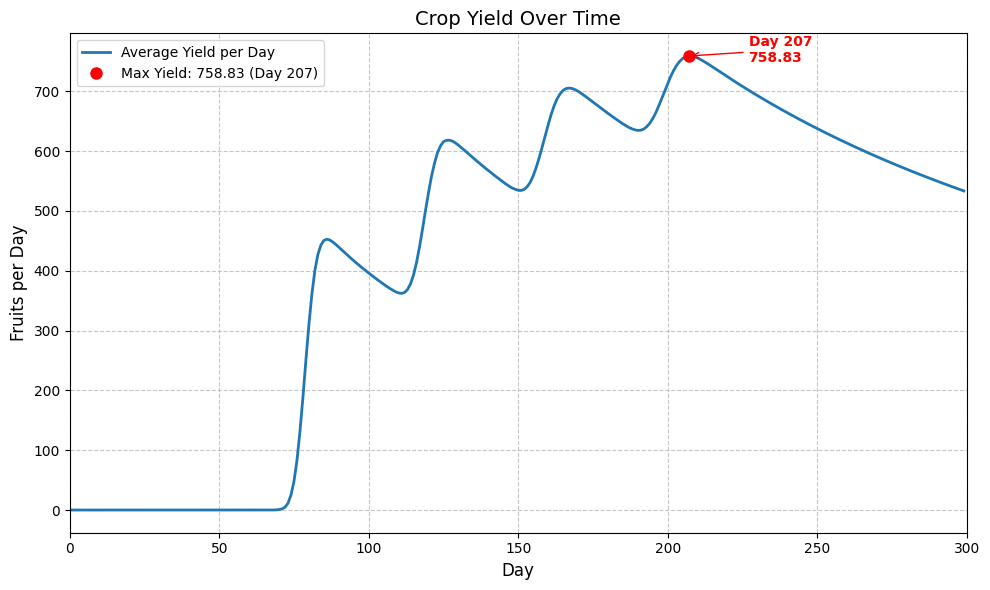

In [192]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
growth = np.zeros((N, N))
fruits = []
yield_per_day = []

for day in range(300):
    random_increment = np.random.uniform(0.01, 0.04, size=growth.shape)
    growth += np.where(growth < 5, random_increment, 0)
    total_fruits = np.maximum(0, np.floor(growth) - 1).sum()
    fruits.append(total_fruits)
    yield_per_day.append(total_fruits / (day + 1))

yield_per_day = np.array(yield_per_day)
max_yield = yield_per_day.max()
max_day = yield_per_day.argmax()


plt.figure(figsize=(10, 6))
plt.plot(yield_per_day, label='Average Yield per Day', linewidth=2)
plt.plot(max_day, max_yield, 'ro', markersize=8, label=f'Max Yield: {max_yield:.2f} (Day {max_day})')
plt.annotate(f'Day {max_day}\n{max_yield:.2f}', 
             xy=(max_day, max_yield), 
             xytext=(max_day + 20, max_yield - 10),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             color='red',
             weight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Fruits per Day', fontsize=12)
plt.title('Crop Yield Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 300)
plt.tight_layout()
plt.savefig("4(a)Yield.png")
plt.show()

After repeated experiments, the optimal frequency is 207-208 days, which corresponds to a daily yield of 757-760 fruits per planting day. In other words, waiting for most crops to produce 4 fruits is relatively more efficient.

## Part b

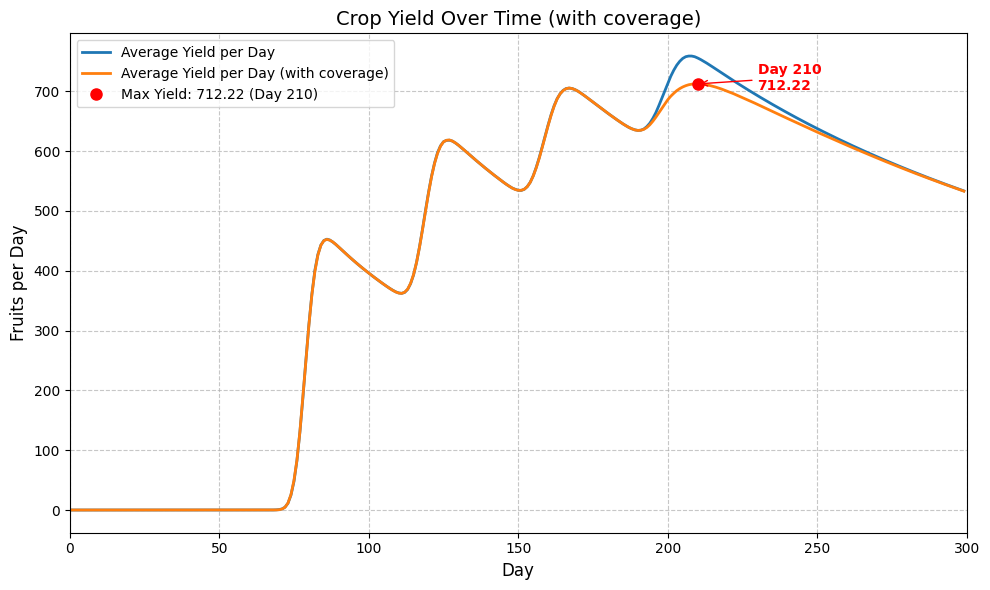

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

N = 200
growth = np.zeros((N, N))
fruits = []
yield_per_day_2 = []
kernel = np.ones((3, 3))

for day in range(300):
    # shaders
    canopy_mask = (growth >= 5).astype(int)
    shade_count = convolve2d(canopy_mask, kernel, mode='same', boundary='fill')
    growth_factor = np.maximum(0, 1 - shade_count / 9)
    
    random_increment = np.random.uniform(0.01, 0.04, size=growth.shape)
    increment = np.where(growth < 5, random_increment * growth_factor, 0) # convolution
    growth += increment
    
    total_fruits = np.maximum(0, np.floor(growth) - 1).sum()
    fruits.append(total_fruits)
    yield_per_day_2.append(total_fruits / (day + 1))

yield_per_day_2 = np.array(yield_per_day_2)
max_yield = yield_per_day_2.max()
max_day = yield_per_day_2.argmax()


plt.figure(figsize=(10, 6))
plt.plot(yield_per_day, label='Average Yield per Day', linewidth=2) # the former yield
plt.plot(yield_per_day_2, label='Average Yield per Day (with coverage)', linewidth=2)
plt.plot(max_day, max_yield, 'ro', markersize=8, label=f'Max Yield: {max_yield:.2f} (Day {max_day})')
plt.annotate(f'Day {max_day}\n{max_yield:.2f}', 
             xy=(max_day, max_yield), 
             xytext=(max_day + 20, max_yield - 10),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             color='red',
             weight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Fruits per Day', fontsize=12)
plt.title('Crop Yield Over Time (with coverage)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 300)
plt.tight_layout()
plt.savefig("4(b)Yield_with_coverage.png")
plt.show()

As can be seen from the figure, as the canopy blocks the sunlight, the speed at which the crop produces 4 fruits slows down overall, and the output efficiency drops significantly, approaching the level of harvesting after 3 fruits.